In [ ]:
#imports
#from biblioteca.modulo import funcion
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sv
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
#from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA



pd.set_option('display.max_columns', 200)

In [ ]:
#importing day_csv data

day_csv = "data/day.csv"
day_df= pd.read_csv(day_csv)

In [ ]:
report = sv.analyze(day_df)
report.show_html("report.html")

DAY_CSV DATA UNDERSTANDING

In [ ]:
day_df.dtypes

In [ ]:
day_df.describe()

In [ ]:
day_df.head(20)

In [ ]:
day_df.isna().sum()

In [ ]:
#importing hour_csv data
hour_csv = "data/hour.csv"
hour_df = pd.read_csv(hour_csv)

HOUR_CSV DATA UNDERSTANDING

In [ ]:
report_hour = sv.analyze(hour_df)
report_hour.show_html("report.html")

In [ ]:
hour_df.shape

In [ ]:
hour_df.dtypes

In [ ]:
hour_df.describe()

In [ ]:
hour_df.head()

In [ ]:
hour_df.isna().sum()

DATA CLEANING

In [ ]:
#no duplicated values
print(f'Valores duplicados en day_csv: {day_df.duplicated().sum()}')
print(f'Valores duplicados en hour_csv: {hour_df.duplicated().sum()}')

In [ ]:
#transforming dteday into datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
display(day_df['dteday'].describe())
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])
display(hour_df['dteday'].describe())

In [ ]:
#renaming columns and dropping somes
day_df = day_df.rename(columns={'dteday':'date',
                       'weathersit':'weather',
                       'yr':'year',
                       'mnth':'month',
                       'cnt':'rented_bikes'
                       })

In [ ]:
hour_df = hour_df.rename(columns={'dteday':'date',
                       'weathersit':'weather',
                       'yr':'year',
                       'mnth':'month',
                       'cnt':'rented_bikes',
                       'hr':'hour'
                       })

In [ ]:
#exploratory data analysis
#there's missing hours on our dataset. We need a complete dataset if we want a model working properly

# 1. create a new column combining date and time. We use timedelta because to a timestamp we can only add duration
hour_df['datetime'] = pd.to_datetime(hour_df['date']) + pd.to_timedelta(hour_df['hour'], unit='h')

# 2. create the perfect range
complete_range = pd.date_range(
    start=hour_df['datetime'].min(), 
    end=hour_df['datetime'].max(), 
    freq='h' # 'h' means hourly frequency
)
    
# 3. we do difference to subtract the new column values to our perfect range (complete calendar)
#we do this because we need to know how many hours are we missing, so we can index them perfectly
missing_hours = complete_range.difference(hour_df['datetime']) 

# --- SHOW RESULTS ---
print(f"all missing hours detected: {len(missing_hours)}")
display(missing_hours[:10]) #we show the first 10 so we see everything is ok

# 4. indexing the new data. This will generate len(missing_hours) rows with NaN as a value for all of them
hour_df_reindex = hour_df.set_index('datetime')
completed_hour_df = hour_df_reindex.reindex(complete_range)

# 5. refilling data 
final_hour_df = completed_hour_df.copy()
#numerical_cols are the columns that only have numerical values (temperature, humidity...)
numerical_cols = completed_hour_df.select_dtypes(include=['number']).columns 
#interpolate only numerical columns
final_hour_df[numerical_cols] = completed_hour_df[numerical_cols].interpolate(method='time')
#fill not numerical columns so we dont break the model. This takes previous column text and put it on the empty next one
final_hour_df = final_hour_df.ffill()


In [ ]:
#we create a general configuration for our graphics
sns.set_theme (
    style = 'whitegrid',
    palette = 'muted',
    context = 'talk',
    rc = {
        'figure.figsize' : (8,5),
        'axes.titlesize' : 16,
        'axes.labelsize' : 12
    },
)

In [ ]:
#first, histogram

sns.barplot(data=day_df, x='month', y='rented_bikes', color = 'teal')

plt.title('General information')
plt.xlabel('Months') 
plt.ylabel('Total bikes rented')
plt.show()

In [ ]:
final_hour_df.columns

In [ ]:
display(final_hour_df.head())

In [ ]:
#searching for outliers. The best way is creating a boxplot

#clean_hours = final_hour_df.index.hour
ax = sns.boxplot(data=day_df, x='month', y='rented_bikes', color = 'teal')
plt.xlabel('months')
plt.ylabel('Rented bikes')
plt.show()


Según he mirado en internet, en octubre de 2012 hubo un huracán tremendo (huracán sandy), por eso en octubre podemos ver que el bigote llega hasta el número 0 de bicicletas alquiladas (https://www.bbc.com/mundo/noticias/2012/10/121029_livetext_supertormenta_sandy_ao). 

In [ ]:
day_df.columns

In [ ]:

#PASO 2. CUMPLIR CON LOS REQUISITOS DE PANDAS
#índice: DatetimeIndex
#asegurar orden cronológico
#asegurar frecuencia constante

#índice
day_df = day_df.set_index('date').sort_index() #establecemos índice y orden cronológico
day_df = day_df.asfreq('D') #frecuencia

In [ ]:
#para comprobar que todo ha funcionado bien:
#day_df.head()
#type(day_df.index)
day_df.index.freq

In [ ]:
#Definición de la serie temporal. Gráficos que demuestren la temporalidad. Buscar tendencia y estacionalidad.
res_semanal = seasonal_decompose(day_df['rented_bikes'], model='additive', period=7)
fig, (ax1, ax2, ax3) = plt.subplots(3,1, figsize=(10, 8), sharex=True)
res_semanal.trend.plot(ax=ax1, color='orange')
ax1.set_title("Trend")
res_semanal.seasonal.plot(ax=ax2, color='teal')
ax2.set_title("Seasonal")
res_semanal.resid.plot(ax=ax3, color="#80B3FF")
ax3.set_title("Resid")


In [ ]:
res_anual = seasonal_decompose(day_df['rented_bikes'], model='additive', period=365)
fig, (ax1, ax2, ax3) = plt.subplots(3,1, figsize=(10, 8), sharex=True)
res_anual.trend.plot(ax=ax1, color='orange')
ax1.set_title("Trend")
res_anual.seasonal.plot(ax=ax2, color='teal')
ax2.set_title("Seasonal")
res_anual.resid.plot(ax=ax3, color="#80B3FF")
ax3.set_title("Resid")

Vale, el trend sale así porque, para calcular correctamente la tendencia anual, el algoritmo necesita mirar un año hacia atrás y un año hacia adelante en cada punto para hacer una media móvil. Como en nuestro dataset solamente tiene datos durante dos años, (730 días en el eje x), la función pierde los primeros y últimos 180 días porque no tiene ni presente ni futuro suficiente para calcular la media anual. Sin embargo, vemos un crecimiento limpio y constante.

In [ ]:
#Transformaciones de la serie. Aplicamos el logaritmo y hacemos la diferenciación para eliminar la tendencia y hacer la serie estacionaria.
diff_serie= np.log(day_df['rented_bikes']).diff() #aquí la diferenciación. Más tarde la usaremos para el modelo. Como solo hemos necesitado una diferenciación,
#en el modelo arima será igual a 1

In [ ]:
diff_serie.plot()

La serie tiene una gran heterocedasticidad, es decir, una gran variabilidad que cambia según la época del año. Vemos lo del huracán sandy en el mes de octubre aquí también.

In [ ]:
#Función de autocorrelación simple (ACF) y parcial (PACF)
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15,5))

plot_acf(diff_serie.dropna(), lags=30, ax=ax1, color='teal')
ax1.set_title("Autocorrelación simple")

plot_pacf(diff_serie.dropna(), lags=30, ax=ax2, color='orange')
ax2.set_title("Autocorrelación parcial")

plt.show();

ACF: el lag 0 siempre es 1. En el lag 1 hay una barra que sobresale hacia abajo, fuera de la sobra azul (la sombra azul es ruido). El resto de lags es normal, esto significa que mi serie es estacionaria. Esta es la p del modelo arima.
PACF: decrecimiento gradual según avanzamos, este es el comportamiento de la media móvil. Esta es la q del modelo arima.

estimación del modelo ARIMA (P,D,Q)
diferenciación: las veces que he tenido que aplanarla (solo 1)
media móvil: mirar gráfico AFC. q=1
término autoregresivo: mirar gráfico PACF. Cuando la AFC corta en 1 y la PACF decrece, probamos p=0 y q=1
ARIMA(0,1,1) o ARIMA (1,1,1) sobre el logaritmo

In [ ]:
#modelo arima. ARIMA(data, order=(p,d,q))
#esta manera de hacerlo es más limpio
p,d,q=0,1,1
model = ARIMA(np.log(day_df['rented_bikes']), order=(p,d,q))
model_fit = model.fit()
model_summary = model_fit.summary()
model_summary

Tanto como el coeficiente como el p-valor están correctos, lo único que falla son los residuos, que no siguen una distribución normal, seguramente por el huracán sandy. Los analizamos. Lo ideal sería hacer un ACF y un PACF solamente de los residuos.

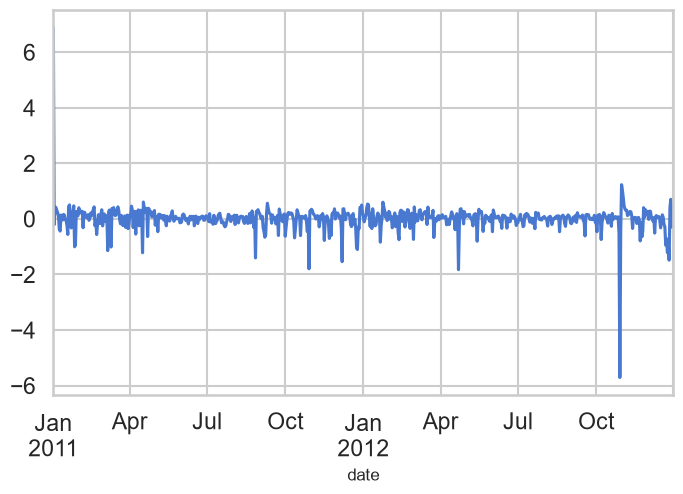

In [38]:
residuals = model_fit.resid
residuals.plot()
#residuals.plot(kind='kde')
plt.show() 

Vemos como, efectivamente, en el mes de octubre baja hasta cerca de -6. Fue en octubre cuando tuvo lugar el huracán Sandy.